### GAN (5 pts)

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
import torchvision.datasets as datasets
import imageio
import numpy as np
import matplotlib
from torchvision.utils import make_grid, save_image
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from tqdm import tqdm
matplotlib.style.use('ggplot')

In [ ]:
# learning parameters
batch_size = 512
epochs = 200
sample_size = 64 # fixed sample size
nz = 128 # latent vector size
k = 1 # number of steps to apply to the discriminator
device = 'cpu'

In [ ]:
transform = transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize((0.5,),(0.5,)),
])
to_pil_image = transforms.ToPILImage()

In [ ]:
train_data = datasets.MNIST(
    root='../input/data',
    train=True,
    download=True,
    transform=transform
)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 133MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 37.8MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 103MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]


In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_vector_size):
        super().__init__()
        self.latent_dim = latent_vector_size

        self.hidden_sizes = [256, 512, 1024]
        self.output_pixels = 784
        self.image_channels = 1
        self.image_height = 28
        self.image_width = 28

        self.transform_pipeline = self._build_architecture()

    def _build_architecture(self):
        layers = []
        current_dim = self.latent_dim

        for hidden_dim in self.hidden_sizes:
            layers.extend([
                nn.Linear(current_dim, hidden_dim),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(hidden_dim, momentum=0.9)
            ])
            current_dim = hidden_dim

        layers.extend([
            nn.Linear(current_dim, self.output_pixels),
            nn.Tanh()
        ])

        return nn.Sequential(*layers)

    def forward(self, latent_vectors):
        pixel_values = self.transform_pipeline(latent_vectors)
        return pixel_values.view(-1, self.image_channels, self.image_height, self.image_width)

    def get_parameter_count(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [ ]:
class Discriminator(nn.Module):
  def __init__(self):
          super().__init__()
          self.input_features = 784
          self.classifier = self._build_classifier()

  def _build_classifier(self):
        layers = []
        layer_configs = [
            (512, 0.3),
            (256, 0.3),
            (128, 0.3)
        ]

        current_dim = self.input_features
        for out_dim, dropout_rate in layer_configs:
            layers.extend([
                nn.Linear(current_dim, out_dim),
                nn.LeakyReLU(negative_slope=0.2, inplace=True),
                nn.Dropout(dropout_rate)
            ])
            current_dim = out_dim

        layers.extend([
            nn.Linear(current_dim, 1),
            nn.Sigmoid()
        ])

        return nn.Sequential(*layers)

  def forward(self, images):
        flattened = images.view(images.size(0), -1)
        return self.classifier(flattened)

In [ ]:
generator = Generator(nz).to(device)
discriminator = Discriminator().to(device)

In [ ]:
optim_g = optim.Adam(generator.parameters(), lr=0.0002)
optim_d = optim.Adam(discriminator.parameters(), lr=0.0002)

In [ ]:
criterion = nn.BCELoss()

In [ ]:
losses_g = []
losses_d = []
images = []

In [ ]:
def label_real(size):
    data = torch.ones(size, 1)
    return data.to(device)
def label_fake(size):
    data = torch.zeros(size, 1)
    return data.to(device)

In [ ]:
def create_noise(sample_size, nz):
    return torch.randn(sample_size, nz).to(device)

In [ ]:
def save_generator_image(image, path):
    save_image(image, path)

In [ ]:
def train_discriminator(optimizer, data_real, data_fake):
    b_size = data_real.size(0)
    real_label = label_real(b_size)
    fake_label = label_fake(b_size)
    optimizer.zero_grad()
    output_real = discriminator(data_real)
    loss_real = criterion(output_real, real_label)
    output_fake = discriminator(data_fake)
    loss_fake = criterion(output_fake, fake_label)
    loss_real.backward()
    loss_fake.backward()
    optimizer.step()
    return loss_real + loss_fake

In [ ]:
def train_generator(optimizer, data_fake):
    b_size = data_fake.size(0)
    real_label = label_real(b_size)
    optimizer.zero_grad()
    output = discriminator(data_fake)
    loss = criterion(output, real_label)
    loss.backward()
    optimizer.step()
    return loss

In [ ]:
noise = create_noise(sample_size, nz)
generator.train()
discriminator.train()

Discriminator(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

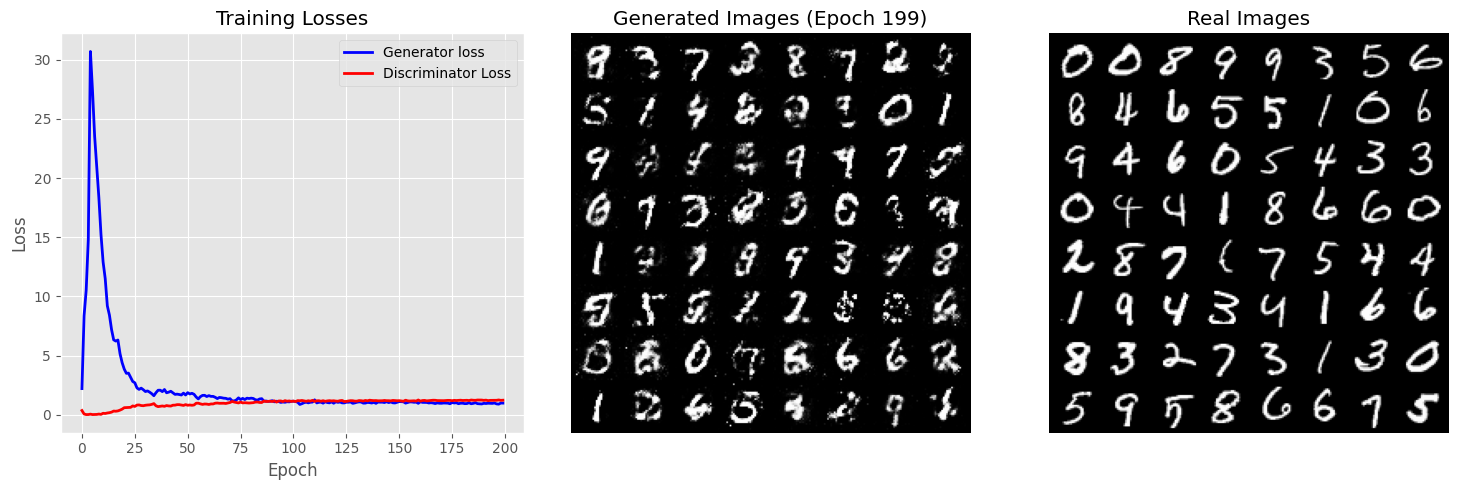

In [ ]:
from IPython.display import clear_output

losses_g = []
losses_d = []
images = []

for epoch in range(epochs):
    loss_g = 0.0
    loss_d = 0.0

    for bi, data in enumerate(tqdm(train_loader, desc=f'Epoch {epoch}')):
        image, _ = data
        image = image.to(device)
        b_size = len(image)

        for step in range(k):
            data_fake = generator(create_noise(b_size, nz)).detach()
            data_real = image
            loss_d += train_discriminator(optim_d, data_real, data_fake)

        data_fake = generator(create_noise(b_size, nz))
        loss_g += train_generator(optim_g, data_fake)

    generated_img = generator(noise).cpu().detach()
    generated_img = make_grid(generated_img, nrow=8, normalize=True)
    images.append(generated_img)

    epoch_loss_g = (loss_g / (bi + 1)).item() if torch.is_tensor(loss_g) else loss_g / (bi + 1)
    epoch_loss_d = (loss_d / (bi + 1)).item() if torch.is_tensor(loss_d) else loss_d / (bi + 1)

    losses_g.append(float(epoch_loss_g))
    losses_d.append(float(epoch_loss_d))

    clear_output(wait=True)
    print(f"Epoch {epoch} of {epochs}")
    print(f"Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}")

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(range(len(losses_g)), losses_g, label='Generator loss', color='blue', linewidth=2)
    plt.plot(range(len(losses_d)), losses_d, label='Discriminator Loss', color='red', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Losses')
    plt.legend()
    plt.grid(True)


    plt.subplot(1, 3, 2)
    plt.imshow(np.transpose(generated_img.numpy(), (1, 2, 0)))
    plt.title(f'Generated Images (Epoch {epoch})')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    real_grid = make_grid(image[:64].cpu(), nrow=8, normalize=True)
    plt.imshow(np.transpose(real_grid.numpy(), (1, 2, 0)))
    plt.title('Real Images')
    plt.axis('off')

    plt.tight_layout()
    plt.show()